In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pandas import DataFrame, Series, Index
from sklearn.feature_selection import mutual_info_regression
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import f_oneway

# 1. Problem formulation

1. **Use case:** *Predict the final house sale price to support property valuation, pricing strategy, and investment analysis.*
2. **Unit of prediction:** *One property listing (house) represented by a single row of structured features describing its characteristics.*
3. **Metrics:** *RMSE*
4. **Target:** *SalePrice*

## 2. Data
**dataset** [https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/overview]

# 3. Explority Data Analisys

In [2]:
# loading of dataset
df = pd.read_csv("../data/house_train.csv")

In [3]:
y = df['SalePrice']
X = df.drop(columns=['SalePrice'])

## - Dataset overview (dataset size, feature count, missings, types)

In [4]:
 df.head(10)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,307000
7,8,60,RL,NaN,10382,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,1,2008,WD,Normal,118000


In [5]:
X.shape

(1460, 80)

**-- there are no many samples (1460) and so there is a risk of overfitting --**

In [6]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

In [7]:
# numeric features
numeric_features = X.select_dtypes(include='number')

# numeric as categorical features
cat_as_num_features = X[['OverallQual', 'OverallCond', 'MSSubClass']]
numeric_features = numeric_features.drop(columns=cat_as_num_features)

# all cat features
categor_features = X.select_dtypes(exclude='number')
categor_features = pd.concat([categor_features, cat_as_num_features]).astype(str)

# ordinal cat features
ordinal_features = [
    "LotShape",
    "LandSlope",
    "ExterQual",
    "ExterCond",
    "BsmtQual",
    "BsmtCond",
    "BsmtExposure",
    "BsmtFinType1",
    "BsmtFinType2",
    "HeatingQC",
    "KitchenQual",
    "Functional",
    "FireplaceQu",
    "GarageFinish",
    "GarageQual",
    "GarageCond",
    "PavedDrive",
    "PoolQC",
    "Fence",
    "OverallQual",
    "OverallCond"
]

# nominal cat features
nominal_features = [
    "MSZoning",
    "Street",
    "Alley",
    "LandContour",
    "Utilities",
    "LotConfig",
    "Neighborhood",
    "Condition1",
    "Condition2",
    "BldgType",
    "HouseStyle",
    "RoofStyle",
    "RoofMatl",
    "Exterior1st",
    "Exterior2nd",
    "MasVnrType",
    "Foundation",
    "Heating",
    "CentralAir",
    "Electrical",
    "GarageType",
    "MiscFeature",
    "SaleType",
    "SaleCondition",
    "MSSubClass"
]

In [8]:
(numeric_features.columns, categor_features.columns, cat_as_num_features.columns)

(Index(['Id', 'LotFrontage', 'LotArea', 'YearBuilt', 'YearRemodAdd',
        'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
        '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
        'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
        'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea',
        'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch',
        'ScreenPorch', 'PoolArea', 'MiscVal', 'MoSold', 'YrSold'],
       dtype='str'),
 Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
        'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
        'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
        'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
        'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
        'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual

In [9]:
# rows with many missing values (threshold = 80%)
samples = X.isnull().mean(axis=1) 
rows_with_many_missing_values = samples[samples > 0.80].index.values
rows_with_many_missing_values

array([], dtype=int64)

In [10]:
def dataset_overview_report(df: DataFrame) -> DataFrame:
    report = pd.DataFrame({
        "dtype": df.dtypes,
        "missing_percent": df.isnull().mean() * 100,
        "unique": df.nunique()
    }).sort_values("missing_percent", ascending=False)
    return report

In [11]:
report = dataset_overview_report(X)
report

,dtype,missing_percent,unique
PoolQC,str,99.520548,3
MiscFeature,str,96.301370,4
Alley,str,93.767123,2
Fence,str,80.753425,4
MasVnrType,str,59.726027,3
...,...,...,...
TotalBsmtSF,int64,0.000000,721
Heating,str,0.000000,6
MSSubClass,int64,0.000000,15
CentralAir,str,0.000000,2


In [12]:
# remove identifier as there is no business information
X = X.drop(columns=['Id'])
numeric_features = numeric_features.drop(columns=['Id'])

## - Target Analysis (positive/negative, distribution, outliers)

In [13]:
y.describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

**min = 34900, max = 755000, mean = ~181000**

<Axes: xlabel='SalePrice', ylabel='Count'>

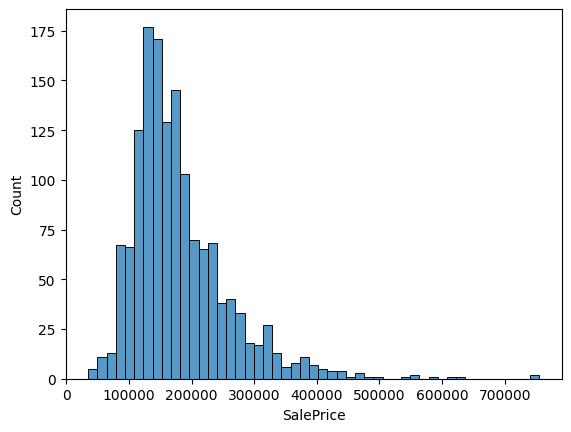

In [14]:
sns.histplot(y)

In [15]:
y.skew()

np.float64(1.8828757597682129)

**there is right skew distribution**

In [16]:
# apply log transformation for SalePrice to get info about outliers
y_log = np.log1p(y)

In [17]:
def check_iqr(s):
    q1 = s.quantile(0.25)
    q3 = s.quantile(0.75)
    IQR = q3 - q1
    top = q3 + 1.5 * IQR
    low = q1 - 1.5 * IQR
    return (low, top)

In [18]:
low, top = check_iqr(y_log)
target_outliers_low = y_log[(y_log < low)]
target_outliers_top = y_log[(y_log > top)]
outliers_percent_low = (len(target_outliers_low)*100)/ df.index.size
outliers_percent_top = (len(target_outliers_top)*100)/ df.index.size
(f'Low - {round(outliers_percent_low, 2)} %', f'Top - {round(outliers_percent_top, 2)} %')

('Low - 1.03 %', 'Top - 0.89 %')

<Axes: xlabel='SalePrice'>

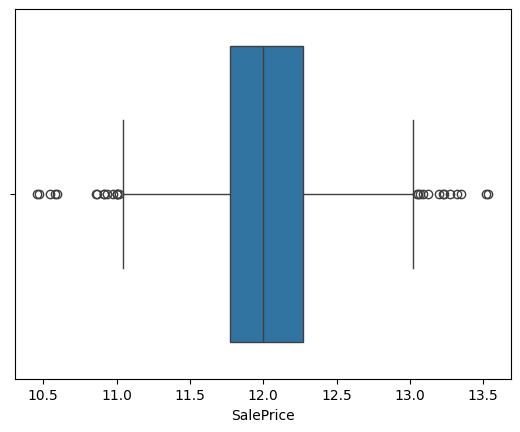

In [19]:
sns.boxplot(x=y_log)

<Axes: xlabel='SalePrice', ylabel='Count'>

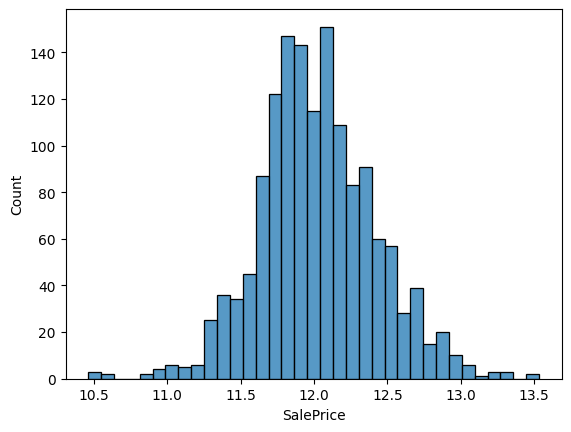

In [20]:
sns.histplot(y_log)

# - Feature Analysis

In [21]:
# for feature analysis were selected skew threshold = 2, outlier threshold = 2%, missing threshold = 30%

LOG_TRANSFORMATION = 'log_transformation'
MISS_DATA_IMPUT_L = 'missings_low'
MISS_DATA_IMPUT_H = 'missings_high'
CREATE_HAS_FEAT = 'create_has_flag'
DROP_CANDIDATE = 'drop_candidate'

def numeric_feature_report(df: DataFrame, columns, skew_threshold = 2, outlier_threshold = 0.02, missing_threshold = 0.3):

    rows = []
    
    for col in columns:
        s = df[col]
        skew = s.skew()
        low, top = check_iqr(s)
        outliers = ((s < low) | (s > top)).mean()
        missings = s.isnull().sum()/len(s)
        constant = s.nunique()

        flags = []
        recommendations = []
        if skew >= skew_threshold:
            flags.append('right_skew')
            recommendations.append(LOG_TRANSFORMATION)

        if skew <= -skew_threshold:
            flags.append('left_skew')

        if outliers > outlier_threshold:
            flags.append('many_outliers')

        if missings > missing_threshold:
            flags.append('many_missings')
            recommendations.append(MISS_DATA_IMPUT_H)

        if missings <= 0.3 and missings > 0:
            recommendations.append(MISS_DATA_IMPUT_L)

        if constant <= 1:
            flags.append('constant')
            recommendations.append(DROP_CANDIDATE)

        if s.median() == 0 and s.quantile(0.01) == 0:
            flags.append('median_zero')
            recommendations.append(CREATE_HAS_FEAT)

        rows.append({
            'feature_name': col,
            'min': s.min(),
            'p1': s.quantile(0.01),
            'mean': s.mean(),
            'median(p50)': s.median(),
            'p99': s.quantile(0.99),
            'max': s.max(),
            'distribution': skew,
            'outliers': outliers*100,
            'missings': missings*100,
            'flags': flags,
            'recommendations': recommendations,
        })

    return DataFrame(rows).sort_values('missings', ascending=False)

In [22]:
nf_report = numeric_feature_report(X, numeric_features)
nf_report

,feature_name,min,p1,mean,median(p50),p99,max,distribution,outliers,missings,flags,recommendations
0,LotFrontage,21.0,21.00,70.049958,69.0,141.00,313.0,2.163569,6.027397,17.739726,"[right_skew, many_outliers]","[log_transformation, missings_low]"
21,GarageYrBlt,1900.0,1916.00,1978.506164,1980.0,2009.00,2010.0,-0.649415,0.000000,5.547945,[],[missings_low]
4,MasVnrArea,0.0,0.00,103.685262,0.0,791.92,1600.0,2.669084,6.575342,0.547945,"[right_skew, many_outliers, median_zero]","[log_transformation, missings_low, create_has_..."
25,OpenPorchSF,0.0,0.00,46.660274,25.0,285.82,547.0,2.364342,5.273973,0.000000,"[right_skew, many_outliers]",[log_transformation]
19,TotRmsAbvGrd,2.0,3.00,6.517808,6.0,11.00,14.0,0.676341,2.054795,0.000000,[many_outliers],[]
20,Fireplaces,0.0,0.00,0.613014,1.0,2.00,3.0,0.649565,0.342466,0.000000,[],[]
22,GarageCars,0.0,0.00,1.767123,2.0,3.00,4.0,-0.342549,0.342466,0.000000,[],[]
23,GarageArea,0.0,0.00,472.980137,480.0,1002.79,1418.0,0.179981,1.438356,0.000000,[],[]
24,WoodDeckSF,0.0,0.00,94.244521,0.0,505.46,857.0,1.541376,2.191781,0.000000,"[many_outliers, median_zero]",[create_has_flag]
26,EnclosedPorch,0.0,0.00,21.954110,0.0,261.05,552.0,3.089872,14.246575,0.000000,"[right_skew, many_outliers, median_zero]","[log_transformation, create_has_flag]"


In [23]:
# for feature analysis were selected rare threshold = 1%, dominant_threshold = 90%, missing threshold = 30%
def categorical_feature_report(df:DataFrame, columns, rare_threshold = 0.01, dominant_threshold = 0.9, missing_threshold = 0.3):

    rows = []
    for col in columns:
        flags = []
        recommendations = []
        
        s:Series = df[col]
        
        missing = s.isnull().sum()/len(s)
        nunique = s.nunique(dropna=True)

        vc = s.value_counts(normalize=True, dropna=True)
        top_cat = vc.index[0] if len(vc) else None
        top_cat_prop = vc.iloc[0] if len(vc) else 0
        rare_cats = vc[vc <= rare_threshold].sum() if len(vc) else 0

        if missing > missing_threshold:
            flags.append('many_missings')
            recommendations.append(MISS_DATA_IMPUT_H)

        if missing < missing_threshold and missing > 0:
            recommendations.append(MISS_DATA_IMPUT_L)

        if nunique <= 1:
            flags.append('constant')
            recommendations.append(DROP_CANDIDATE)

        if top_cat_prop >= dominant_threshold:
            flags.append('dominant')

        if rare_cats > 0.3:
            flags.append('many_rare')

        rows.append({
            'feature_name': col,
            'missings': missing*100,
            'unique': nunique,
            'dominate': top_cat,
            'dominate_prop': top_cat_prop*100,
            'flags': flags,
            'recommendations': recommendations
        })

    return DataFrame(rows).sort_values(by='missings', ascending=False)

In [24]:
cf_report = categorical_feature_report(X, pd.concat([categor_features, cat_as_num_features]))
cf_report

,feature_name,missings,unique,dominate,dominate_prop,flags,recommendations
38,PoolQC,99.520548,3,Gd,42.857143,[many_missings],[missings_high]
40,MiscFeature,96.301370,4,Shed,90.740741,"[many_missings, dominant]",[missings_high]
2,Alley,93.767123,2,Grvl,54.945055,[many_missings],[missings_high]
39,Fence,80.753425,4,MnPrv,55.871886,[many_missings],[missings_high]
17,MasVnrType,59.726027,3,BrkFace,75.680272,[many_missings],[missings_high]
32,FireplaceQu,47.260274,5,Gd,49.350649,[many_missings],[missings_high]
34,GarageFinish,5.547945,3,Unf,43.872371,[],[missings_low]
36,GarageCond,5.547945,5,TA,96.156635,[dominant],[missings_low]
33,GarageType,5.547945,6,Attchd,63.089195,[],[missings_low]
35,GarageQual,5.547945,5,TA,95.068891,[dominant],[missings_low]


## Feature - Target interaction (correlation)

In [25]:
# group by 
feature_missing_imputation_l, feature_missing_imputation_h, feature_log, feature_creating_has, feature_drop = [], [], [], [], []

for _, r in pd.concat([nf_report, cf_report]).iterrows():
    rec = r['recommendations']
    fn = r['feature_name']
    if DROP_CANDIDATE in rec:
        feature_drop.append(fn)
        continue
    if MISS_DATA_IMPUT_H in rec:
        feature_missing_imputation_h.append(fn)
    if MISS_DATA_IMPUT_L in rec:
        feature_missing_imputation_l.append(fn)
    if LOG_TRANSFORMATION in rec:
        feature_log.append(fn)
    if CREATE_HAS_FEAT in rec:
        feature_creating_has.append(fn) 

In [26]:
# temporary preprocessing
X_tmp = X.copy()

categor_features_tmp = categor_features.copy()
cat_as_num_features_tmp = cat_as_num_features.copy()

numeric_features_tmp = numeric_features.copy()
numeric_new_has_features_tmp = DataFrame()

# drop features
for col in feature_drop:
    X_tmp[col] = X_tmp[col].drop(columns=col)
    continue

# missing data imputation for a high percentage (median for numeric, and None for categorical)
for col in feature_missing_imputation_h:
    if X_tmp[col].dtype in [int, float]:
        X_tmp[col] = X_tmp[col].fillna(X_tmp[col].median())
    else:
        X_tmp[col] = X_tmp[col].fillna('None')

# missing data imputation for a low percentage (median for numeric, and mode for categorical)
for col in feature_missing_imputation_l:
    if X_tmp[col].dtype in [int, float]:
        X_tmp[col] = X_tmp[col].fillna(X_tmp[col].median())
    else:
        vc = X_tmp[col].value_counts()
        X_tmp[col] = X_tmp[col].fillna(vc.index[0])

# log transformation
for col in feature_log:
    X_tmp[col] = np.log1p(X_tmp[col])

# create - has_<feature>
for col in feature_creating_has:
    name = 'Has_' + col
    X_tmp[name] = np.where(X_tmp[col] != 0, 1, 0)  
    numeric_new_has_features_tmp[name] = X_tmp[name]

all_numeric_features_tmp = pd.concat([numeric_features_tmp, numeric_new_has_features_tmp])

In [27]:
def numeric_feature_target_report(df: DataFrame, columns: Index, y: Series, corr_threshold = 0.08, mi_threshold = 0.01) -> DataFrame:
    
    rows = []
    for col in columns:
        flags = []
        recommendations = []
        corr_pearson = df[col].corr(y, method='pearson')
        corr_spearman = df[col].corr(y, method='spearman')
        mi = mutual_info_regression(df[[col]], y, random_state=42)

        if abs(corr_pearson) < corr_threshold:
            flags.append('corr_pearson_low')

        if abs(corr_spearman) < corr_threshold:
            flags.append('corr_spearman_low')

        if mi < mi_threshold:
            flags.append('mi_low')

        if set(['corr_pearson_low', 'corr_spearman_low', 'mi_low']).issubset(flags) or 'mi_low' in flags:
            recommendations.append(DROP_CANDIDATE)
        
        rows.append({
            'feature_name': col,
            'corr_pearson': corr_pearson,
            'corr_spearman': corr_spearman,
            'mi': mi[0],
            'flags': flags,
            'recommendations': recommendations,
        })

    return DataFrame(rows)
    

In [28]:
nft_report = numeric_feature_target_report(df=X_tmp, columns=all_numeric_features_tmp, y=y_log)
nft_report.sort_values(by='corr_pearson', ascending=False)

,feature_name,corr_pearson,corr_spearman,mi,flags,recommendations
12,GrLivArea,0.700927,0.731310,0.458023,[],[]
22,GarageCars,0.680625,0.690711,0.358287,[],[]
23,GarageArea,0.650888,0.649379,0.362076,[],[]
8,TotalBsmtSF,0.612134,0.602725,0.363219,[],[]
9,1stFlrSF,0.596981,0.575408,0.298745,[],[]
15,FullBath,0.594771,0.635957,0.266893,[],[]
2,YearBuilt,0.586570,0.652682,0.365712,[],[]
3,YearRemodAdd,0.565608,0.571159,0.240690,[],[]
19,TotRmsAbvGrd,0.534422,0.532586,0.227607,[],[]
21,GarageYrBlt,0.495794,0.563256,0.293025,[],[]


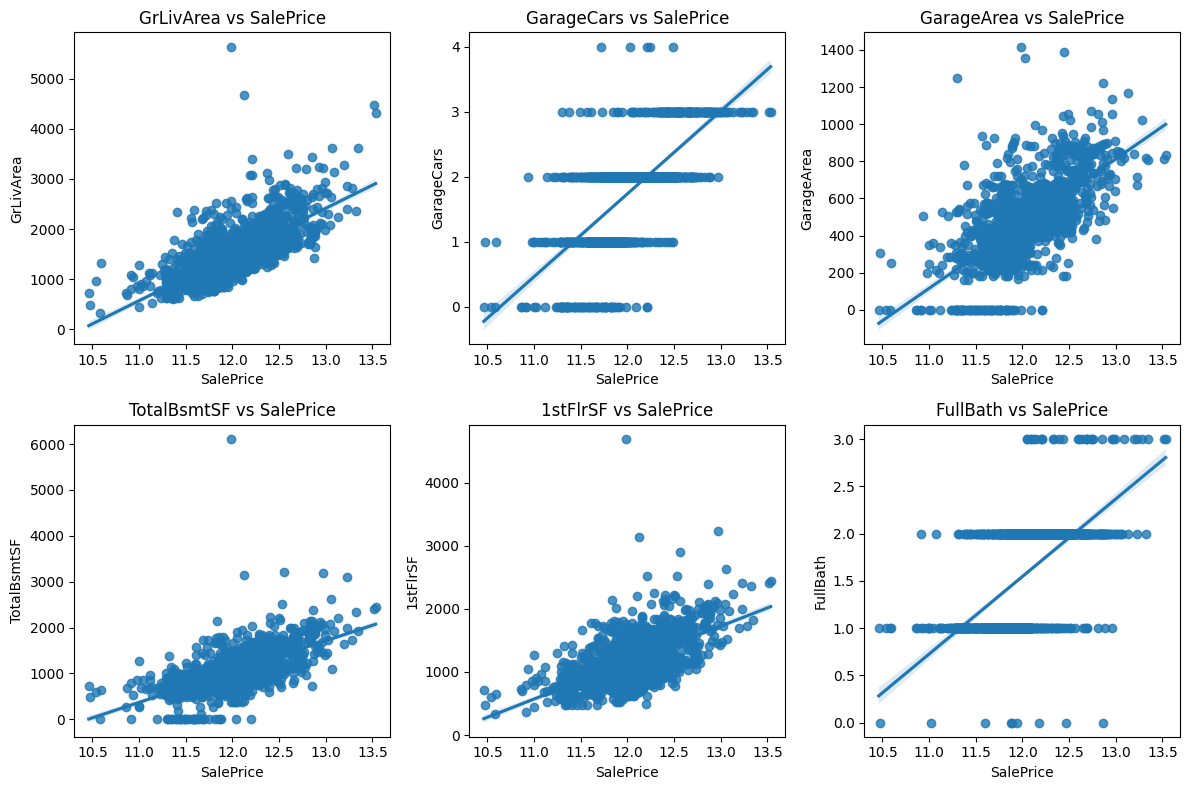

In [29]:
# numeric features <-> target
tmp_report = nft_report.copy()
d = X_tmp.copy()
tmp_report['corr_pearson'] = tmp_report['corr_pearson'].abs()
columns = tmp_report.nlargest(6, ['corr_pearson'])['feature_name']
d['SalePrice'] = y_log

fig, axes = plt.subplots(2, 3, figsize=(12, 8))   # создаём несколько subplot
axes = axes.flatten()

for i, col in enumerate(columns):
    sns.regplot(data=d, x='SalePrice', y=col, ax=axes[i])
    axes[i].set_title(f'{col} vs SalePrice')

plt.tight_layout()
plt.show()

In [30]:
def f_test(df: DataFrame, col: str):
    groups = [
        group['SalePrice'].values
        for name, group in df.groupby(col)
        if len(group) > 1
    ]
        
    if len(groups) > 1:
        return f_oneway(*groups)
    return ('-', '-')

def cat_feature_target_report(df:DataFrame, columns: Index, y:Series, mi_threshold = 0.01) -> DataFrame:
    df_tmp = df.copy()
    df_tmp['SalePrice'] = y
    
    rows = []
    for col in columns:
        flags = []
        recommendations = []

        if col not in df_tmp.columns:
            continue

        # mutual information
        df_tmp[col], _ = pd.factorize(df_tmp[col])
        mi = mutual_info_regression(df_tmp[[col]], y, discrete_features=True, random_state=42)

        if mi < mi_threshold:
            flags.append('mi_low')
            recommendations.append('drop_candidate')

        # ANOVA f_test
        F, p = f_test(df_tmp, col)

        rows.append({
            'feature_name': col,
            'mi':mi[0],
            'f_test': F,
            'flags': flags,
            'recommendations': recommendations,
        })
    return DataFrame(rows).sort_values(by='mi', ascending=False)

In [31]:
cft_report = cat_feature_target_report(X_tmp, pd.concat([categor_features_tmp, cat_as_num_features_tmp]), y_log)
cft_report

,feature_name,mi,f_test,flags,recommendations
43,OverallQual,5.761968e-01,332.16696,[],[]
8,Neighborhood,5.316157e-01,79.520526,[],[]
18,ExterQual,3.279184e-01,415.304259,[],[]
30,KitchenQual,3.248753e-01,393.320922,[],[]
21,BsmtQual,3.132038e-01,381.97473,[],[]
45,MSSubClass,2.823335e-01,50.866063,[],[]
34,GarageFinish,2.444837e-01,389.177818,[],[]
32,FireplaceQu,2.093022e-01,131.198588,[],[]
20,Foundation,1.966438e-01,126.806779,[],[]
27,HeatingQC,1.609106e-01,146.610039,[],[]


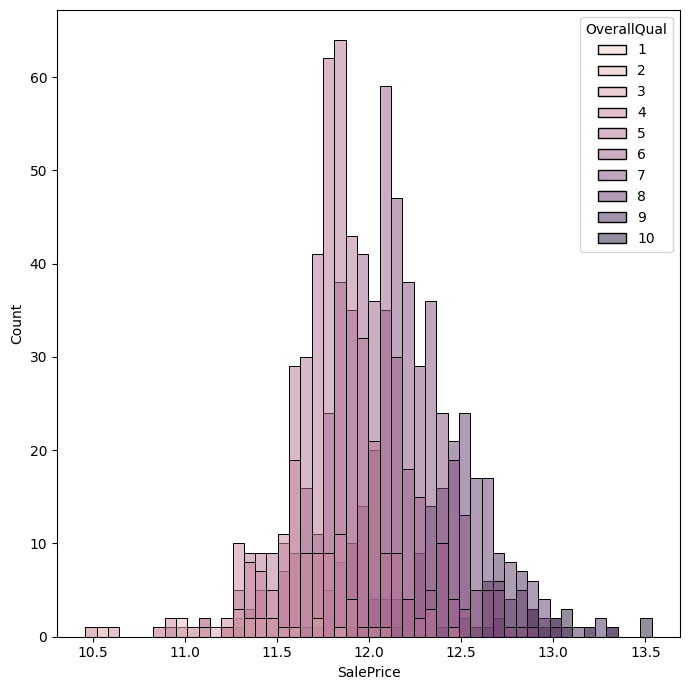

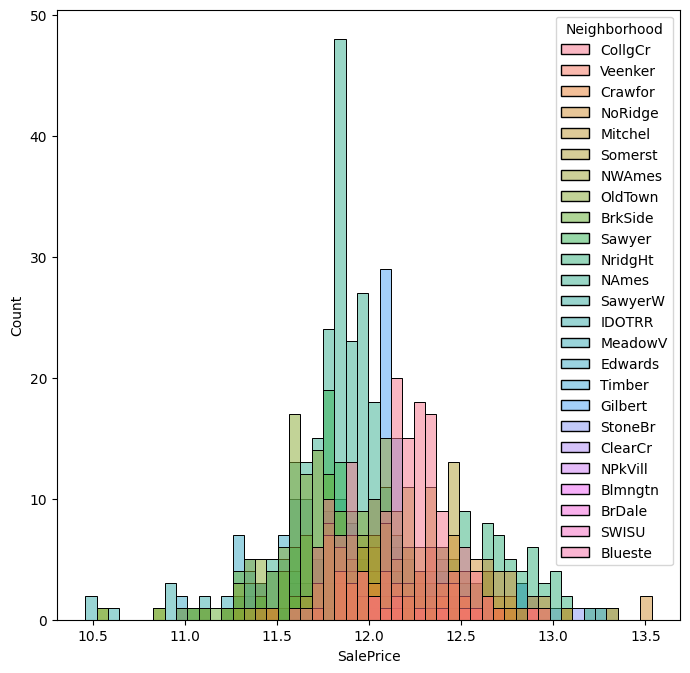

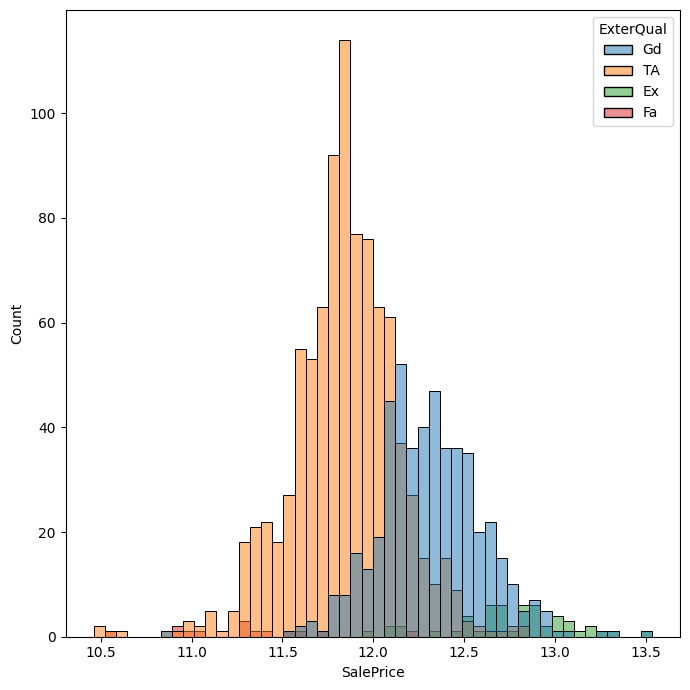

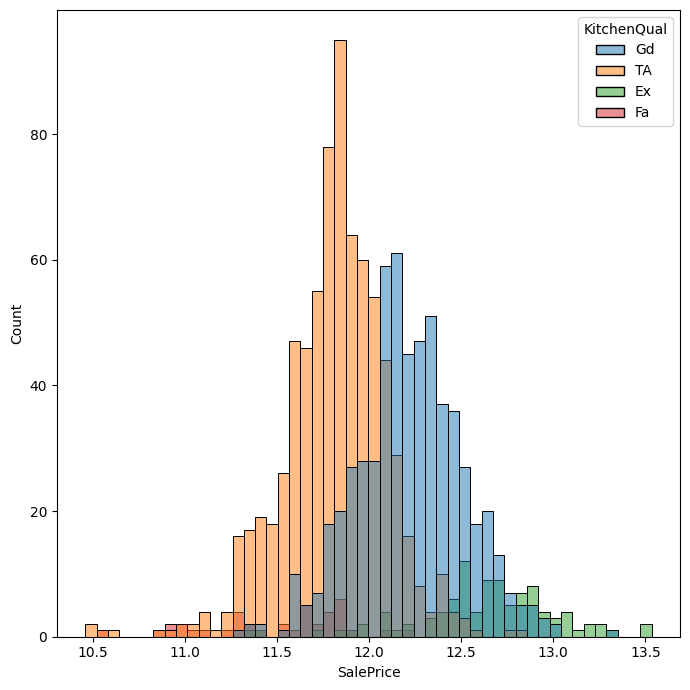

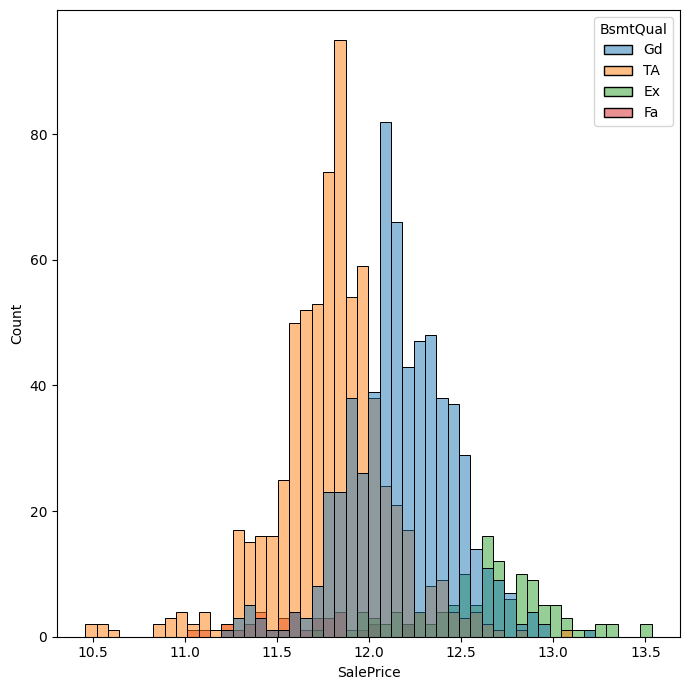

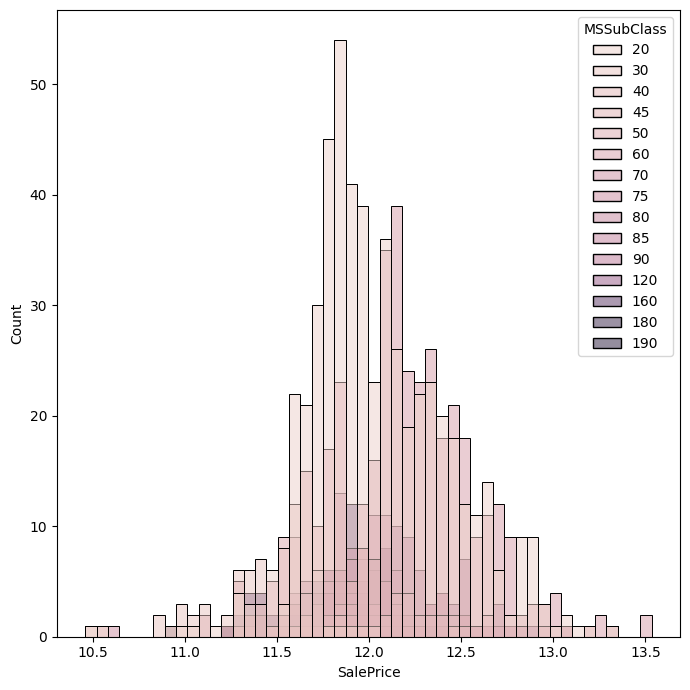

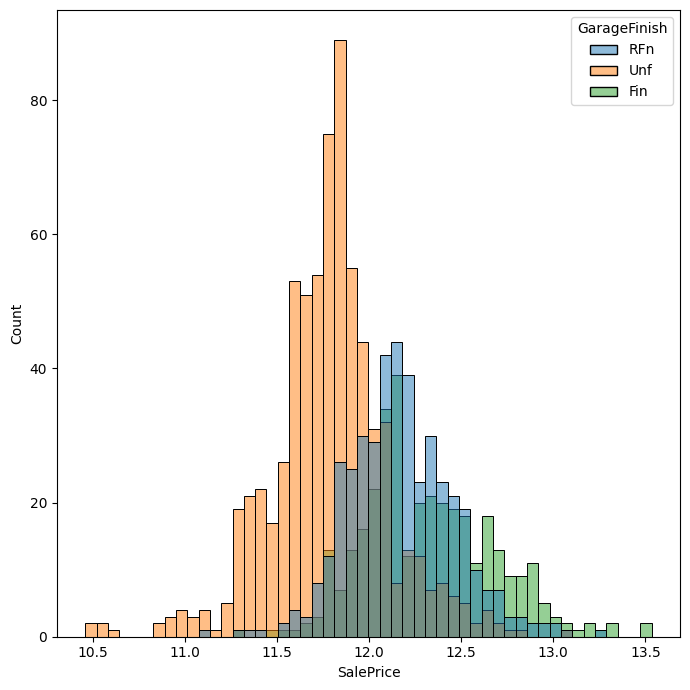

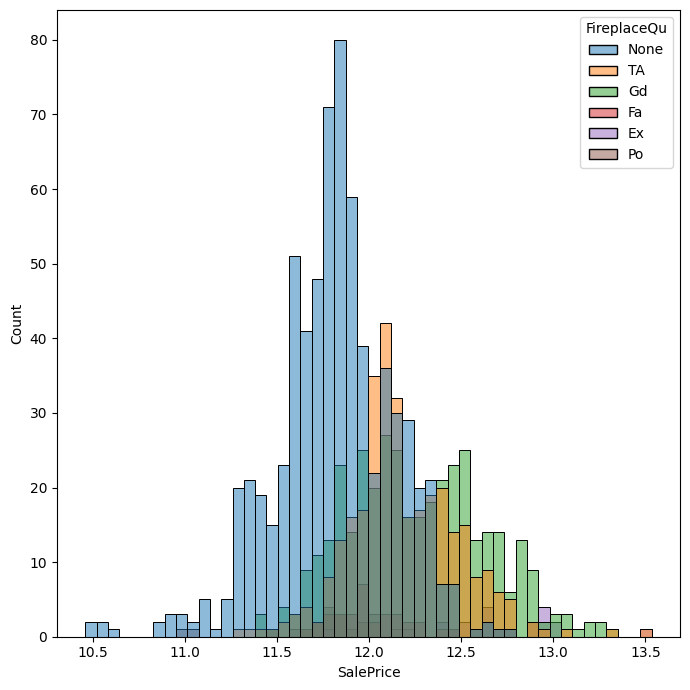

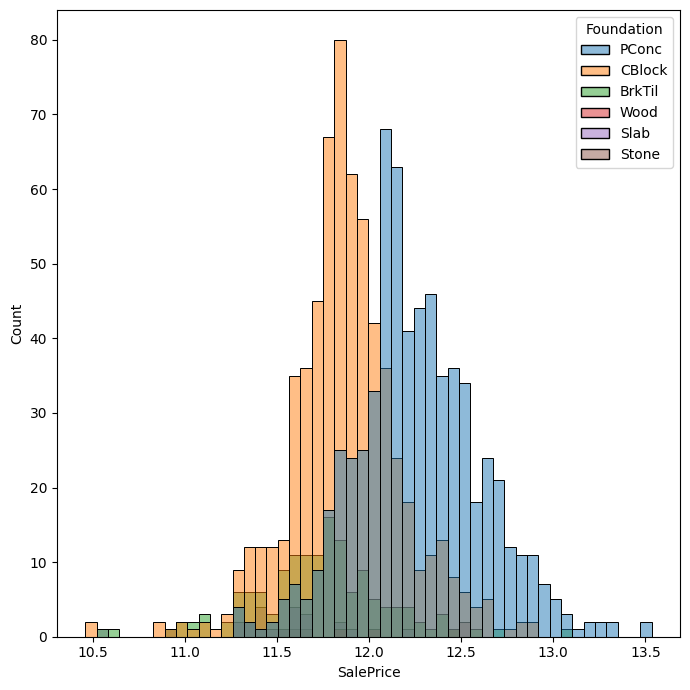

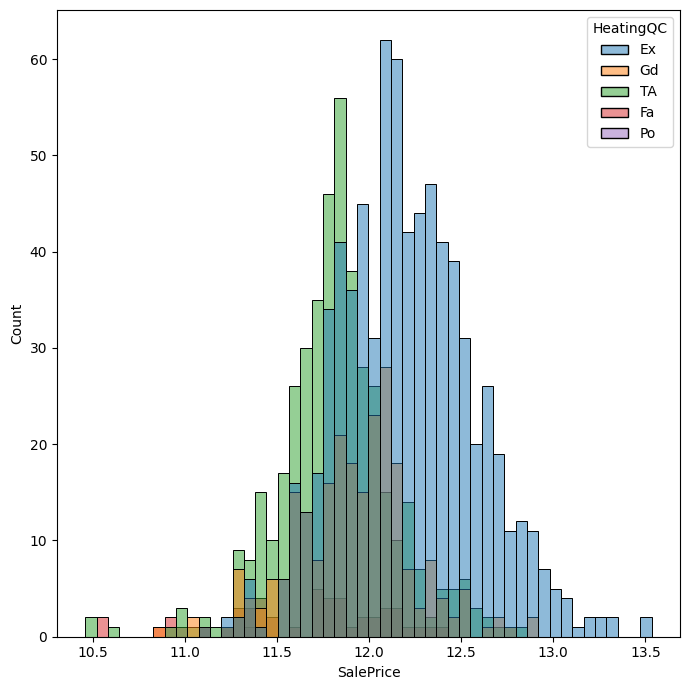

In [32]:
# categorical features <-> target
tmp_report = cft_report.copy()
d = X_tmp.copy()
d['SalePrice'] = y_log
columns = tmp_report.nlargest(10, 'mi')['feature_name']

for col in columns:
    plt.figure(figsize=(7, 7))
    sns.histplot(data=d, x='SalePrice', hue=col, bins=50);
    plt.tight_layout()
plt.show()

## Feature - Feature interaction (correlation, VIF)

In [33]:
# correlation between features (correlation matrix)
corr_pearson_matrix = numeric_features_tmp.corr(method='pearson').abs()
up_val = corr_pearson_matrix.where(np.triu(m=np.ones(corr_pearson_matrix.shape), k=1).astype(bool))
highest_cols = [col for col in up_val.columns if any(up_val[col] > 0.5)]
highest_cols

['YearRemodAdd',
 'TotalBsmtSF',
 '1stFlrSF',
 'GrLivArea',
 'BsmtFullBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'TotRmsAbvGrd',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea']

<Axes: >

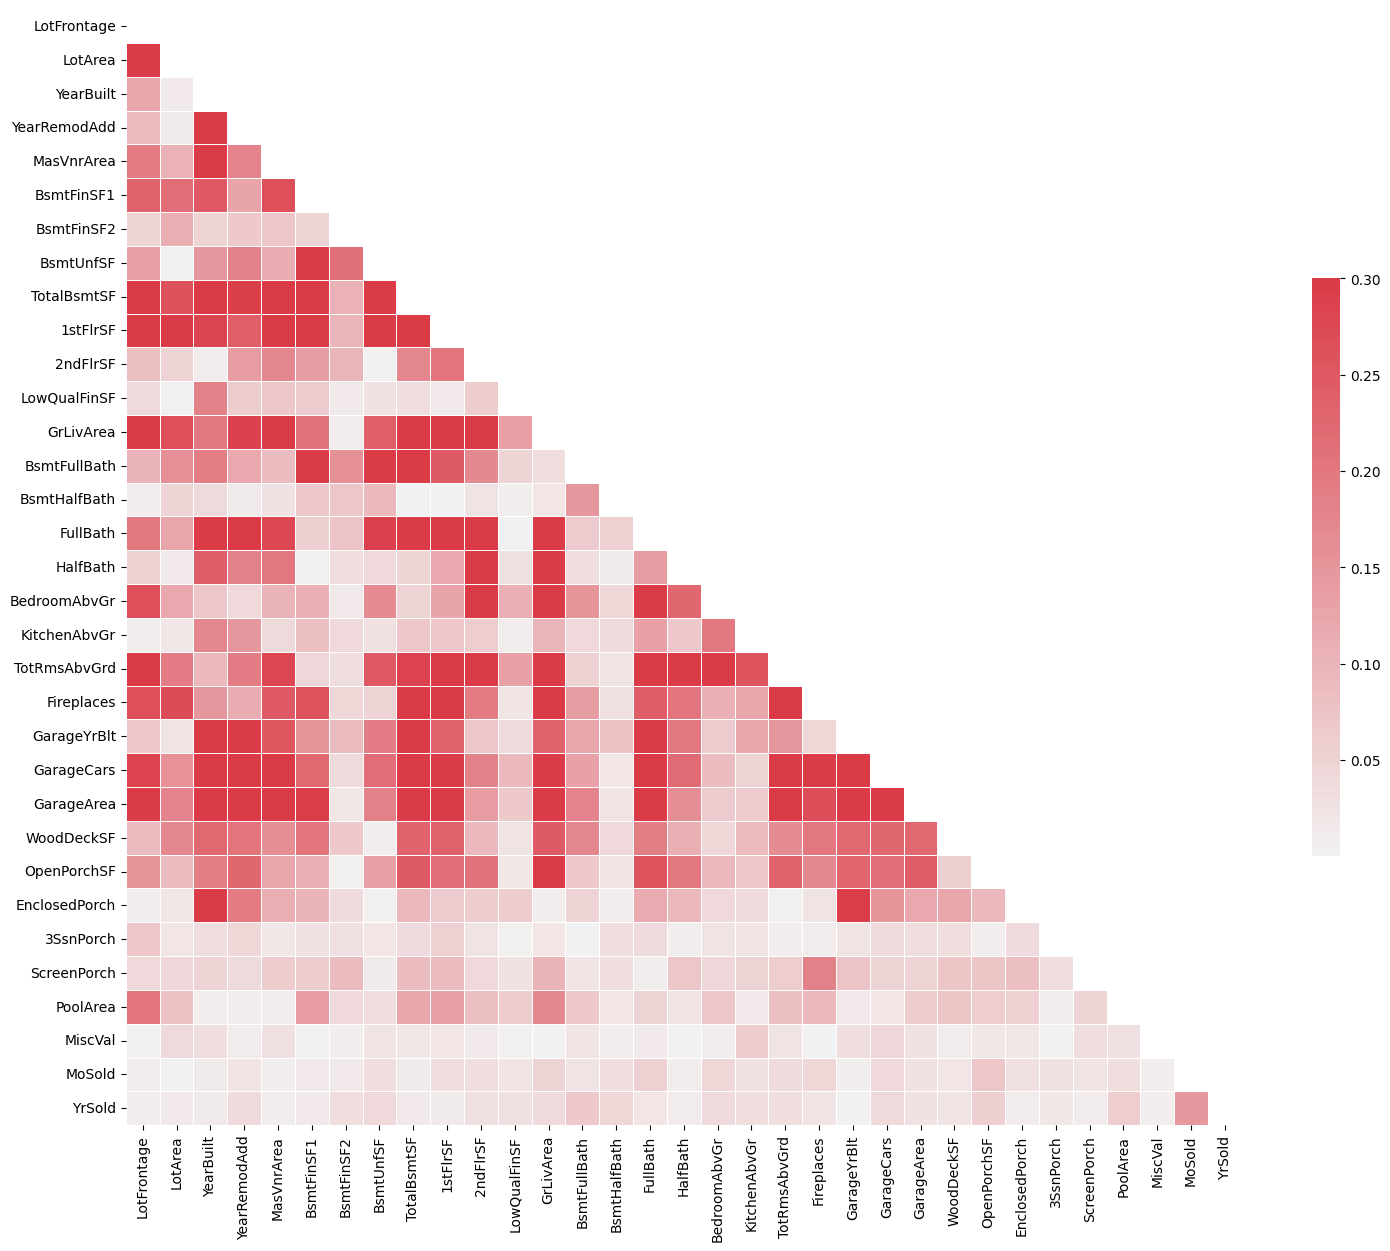

In [34]:
mask = np.zeros_like(corr_pearson_matrix, dtype=np.bool)
mask[np.triu_indices_from(mask)] = True

f, ax = plt.subplots(figsize=(18, 15))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_pearson_matrix, mask=mask, cmap=cmap, vmax=.3, center=0,
            square=True, linewidths=.5, cbar_kws={"shrink": .5})

In [35]:
# Variance Inflation Factor (multicollinearity)
def vif(df: DataFrame, columns):
    df_temp = df.copy()
    vif_data = pd.DataFrame()
    vif_data["feature"] = columns
    vif_data["VIF"] = [
        variance_inflation_factor(df_temp[columns].values, i)
        for i in range(df_temp[columns].shape[1])
    ]
    return vif_data

In [36]:
vif_data = vif(X_tmp, numeric_features_tmp.columns)
print(vif_data.sort_values("VIF", ascending=False))

          feature           VIF
32         YrSold  24334.116184
21    GarageYrBlt  22107.125233
2       YearBuilt  18992.041808
3    YearRemodAdd  18056.617199
12      GrLivArea   9879.607839
9        1stFlrSF   5763.984481
10       2ndFlrSF   1191.128272
1         LotArea    673.065407
0     LotFrontage    343.162366
8     TotalBsmtSF    247.888310
7       BsmtUnfSF     92.972704
18   KitchenAbvGr     85.941581
19   TotRmsAbvGrd     82.627819
5      BsmtFinSF1     69.516420
22     GarageCars     36.317121
23     GarageArea     32.076789
17   BedroomAbvGr     30.633420
15       FullBath     26.666966
11   LowQualFinSF      9.113708
31         MoSold      6.603964
6      BsmtFinSF2      5.102674
13   BsmtFullBath      3.654776
16       HalfBath      3.437420
25    OpenPorchSF      3.067966
20     Fireplaces      2.979847
4      MasVnrArea      2.310519
24     WoodDeckSF      1.903156
26  EnclosedPorch      1.547799
14   BsmtHalfBath      1.227952
28    ScreenPorch      1.203172
29      

In [37]:
# temporary feature engineering
# add AgeHouse instead to keep YrSold - YearBuilt
X_tmp['AgeHouse'] = X_tmp['YrSold'] - X_tmp['YearBuilt']

# add AgeRemodeHouse instead to keep YrSold - YearRemodAdd
X_tmp['AgeRemodeHouse'] = X_tmp['YrSold'] - X_tmp['YearRemodAdd']

# add AgeGarage instead to keep GarageYrBlt
X_tmp['AgeGarage'] = X_tmp['YrSold'] - X_tmp['GarageYrBlt']

numeric_features_tmp[['AgeHouse', 'AgeRemodeHouse', 'AgeGarage']] = X_tmp[['AgeHouse', 'AgeRemodeHouse', 'AgeGarage']]
X_tmp = X_tmp.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt'])
numeric_features_tmp = numeric_features_tmp.drop(columns=['YrSold', 'YearBuilt', 'YearRemodAdd', 'GarageYrBlt'])

# drop features 1stFlrSF and 2ndFlrSF as they are part of the GrLivArea
X_tmp = X_tmp.drop(columns=['1stFlrSF', '2ndFlrSF'])
numeric_features_tmp = numeric_features_tmp.drop(columns=['1stFlrSF', '2ndFlrSF'])

# drop features BsmtFinSF1, BsmtFinSF2, BsmtUnfSF as they are part of the TotalBsmtSF
X_tmp = X_tmp.drop(columns=['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'])
numeric_features_tmp = numeric_features_tmp.drop(columns=['BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF'])

# drop feature LotFrontage as it is part of the LotArea
X_tmp = X_tmp.drop(columns=['LotFrontage'])
numeric_features_tmp = numeric_features_tmp.drop(columns=['LotFrontage'])

# drop TotRmsAbvGrd as it is part of the GrLivArea - (need to check)
X_tmp = X_tmp.drop(columns=['TotRmsAbvGrd'])
numeric_features_tmp = numeric_features_tmp.drop(columns=['TotRmsAbvGrd'])

# drop them as they are part of the common square
X_tmp = X_tmp.drop(columns=['GarageArea', 'KitchenAbvGr', 'BedroomAbvGr', 'FullBath'])
numeric_features_tmp = numeric_features_tmp.drop(columns=['GarageArea', 'KitchenAbvGr', 'BedroomAbvGr', 'FullBath'])

In [38]:
vif(X_tmp, numeric_features_tmp.columns).sort_values(by='VIF', ascending=False)

,feature,VIF
0,LotArea,37.100880
4,GrLivArea,22.778979
2,TotalBsmtSF,13.512068
9,GarageCars,12.427673
18,AgeHouse,9.715518
20,AgeGarage,7.600992
17,MoSold,6.451624
19,AgeRemodeHouse,4.136115
11,OpenPorchSF,2.975746
8,Fireplaces,2.683476


In [40]:
df[['LotArea', 'TotalBsmtSF', 'GrLivArea']]

,LotArea,TotalBsmtSF,GrLivArea
0,8450,856,1710
1,9600,1262,1262
2,11250,920,1786
3,9550,756,1717
4,14260,1145,2198
...,...,...,...
1455,7917,953,1647
1456,13175,1542,2073
1457,9042,1152,2340
1458,9717,1078,1078
